# Taller 1 - Análisis descriptivo

Para el desarrollo de este notebook, se utilizó una base de datos proveniente de [kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) que contiene información de



* People

  -  ID: Customer's unique identifier
  -  Year_Birth: Customer's birth year
  -  Education: Customer's education level
  -  Marital_Status: Customer's marital status
  -  Income: Customer's yearly household income
  -  Kidhome: Number of children in customer's household
  -  Teenhome: Number of teenagers in customer's household
  -  Dt_Customer: Date of customer's enrollment with the company
  -  Recency: Number of days since customer's last purchase
  -  Complain: 1 if the customer complained in the last 2 years, 0 otherwise

* Products

  - MntWines: Amount spent on wine in last 2 years

  - MntFruits: Amount spent on fruits in last 2 years

  - MntMeatProducts: Amount spent on meat in last 2 years

  - MntFishProducts: Amount spent on fish in last 2 years

  - MntSweetProducts: Amount spent on sweets in last 2 years
  
  - MntGoldProds: Amount spent on gold in last 2 years

* Promotion
  
  - NumDealsPurchases: Number of purchases made with a discount
  
  - AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

  - AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

  - AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

  - AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

  - AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

  - Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

* Place
  - NumWebPurchases: Number of purchases made through the company’s website
  - NumCatalogPurchases: Number of purchases made using a catalogue
  - NumStorePurchases: Number of purchases made directly in stores
  - NumWebVisitsMonth: Number of visits to company’s website in the last month


---

Conexión con google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importación de librerías

In [8]:
import pandas as pd # manejo de Data Frame en Python
pd.set_option('display.max_columns', 50) # Aumenta el número de columnas
import numpy as np
# Librería de gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Establecer la ruta donde se van a trabajar el notebook y donde está el archivo.

In [70]:
path= "/content/marketing_campaign.csv" # Colocar la ubicación del archivo
datos= pd.read_csv(path,sep="\t") # Creamos el dataframe con los datos


## Exploración preliminar del archivo

*  Haga una visualización del formato de las primeras 10 filas del dataframe
*  Haga un ``print`` donde diga cuantas filas y columnas tiene el dataframe
*  Presente cual es el nombre de las variables que tiene el dataframe
*  Luego establezca cuantos registros hay con datos faltantes




In [71]:
display(datos.head(10))

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


In [72]:
print(f"El dataframe tiene {datos.shape[0]} filas y {datos.shape[1]} columnas")

El dataframe tiene 2240 filas y 29 columnas


In [73]:
print(datos.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [74]:
rdf=datos.isna().sum()
print(rdf)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


¿Cuántos registros con datos faltantes se eliminaron?

¿Cuántos registros quedan después de eliminar los datos faltantes?


---


In [75]:
datos_sin_na = datos.dropna()
registros_eliminados = len(datos) - len(datos_sin_na)

print(f"Se eliminaron {registros_eliminados} registros con datos faltantes.")
print(f"Quedan {len(datos_sin_na)} registros después de eliminar los datos faltantes.")


Se eliminaron 24 registros con datos faltantes.
Quedan 2216 registros después de eliminar los datos faltantes.


In [76]:

datos_sin_na

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


## Creación de variables

¿Qué variables se necesitan?

Se ha identificado que se deben crear 2 variables nuevas

*  Edad
*  Número de campañas aceptadas en total
*  Número de campañas aceptadas por cliente
*  Número de clientes que aceptaron en cada campaña
*  Número de hijos
*  Tiene hijos



---




In [77]:
# Calcular edad
datos_sin_na['Age'] = 2025 - datos_sin_na['Year_Birth']

# Calcular campañas aceptadas en total
datos_sin_na['Num_total_acep_camp'] = datos_sin_na['AcceptedCmp1'] + datos_sin_na['AcceptedCmp2'] + datos_sin_na['AcceptedCmp3'] + datos_sin_na['AcceptedCmp4'] + datos_sin_na['AcceptedCmp5'] + datos_sin_na['Response']

# Calcular campañas aceptadas por cliente
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
datos_sin_na['Num_acep_camp'] = datos_sin_na[campaigns].sum(axis=1)

# Calcular clientes que aceptaron en cada campaña
num_cust_camp1 = datos_sin_na[datos_sin_na['AcceptedCmp1']==1].shape[0]
num_cust_camp2 = datos_sin_na[datos_sin_na['AcceptedCmp2']==1].shape[0]
num_cust_camp3 = datos_sin_na[datos_sin_na['AcceptedCmp3']==1].shape[0]
num_cust_camp4 = datos_sin_na[datos_sin_na['AcceptedCmp4']==1].shape[0]
num_cust_camp5 = datos_sin_na[datos_sin_na['AcceptedCmp5']==1].shape[0]
num_cust_response = datos_sin_na[datos_sin_na['Response']==1].shape[0]

print(f"Customers accepted in campaign 1: {num_cust_camp1}")
print(f"Customers accepted in campaign 2: {num_cust_camp2}")
print(f"Customers accepted in campaign 3: {num_cust_camp3}")
print(f"Customers accepted in campaign 4: {num_cust_camp4}")
print(f"Customers accepted in campaign 5: {num_cust_camp5}")
print(f"Customers accepted in last campaign: {num_cust_response}")

# Calcular número de hijos
datos_sin_na['Num_hijos'] = datos_sin_na['Kidhome'] + datos_sin_na['Teenhome']


Customers accepted in campaign 1: 142
Customers accepted in campaign 2: 30
Customers accepted in campaign 3: 163
Customers accepted in campaign 4: 164
Customers accepted in campaign 5: 162
Customers accepted in last campaign: 333


<ipython-input-77-48911d0599ad>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_sin_na['Age'] = 2025 - datos_sin_na['Year_Birth']
<ipython-input-77-48911d0599ad>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_sin_na['Num_total_acep_camp'] = datos_sin_na['AcceptedCmp1'] + datos_sin_na['AcceptedCmp2'] + datos_sin_na['AcceptedCmp3'] + datos_sin_na['AcceptedCmp4'] + datos_sin_na['AcceptedCmp5'] + datos_sin_na['Response']
<ipython-input-77-48911d0599ad>:9: SettingWithCopyWarning: 
A value is tryin

In [78]:
# Tiene hijos (Sí/No)
datos_sin_na['Tiene_hijos'] = datos_sin_na['Num_hijos'].apply(lambda x: 1 if x > 0 else 0)

<ipython-input-78-be8653eb4fd3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_sin_na['Tiene_hijos'] = datos_sin_na['Num_hijos'].apply(lambda x: 1 if x > 0 else 0)


In [79]:

datos_sin_na

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Num_total_acep_camp,Num_acep_camp,Num_hijos,Tiene_hijos
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,68,1,1,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,71,0,0,2,1
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,60,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,41,0,0,1,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,44,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0,58,0,0,1,1
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0,79,1,1,3,1
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0,44,1,1,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0,69,0,0,1,1


Eliminar variables

¿Qué variables se podrían eliminar?

Variables que ya se usaron o se cree que no se van a utilizar




---

En este contexto no es necesario borrar variables, esto se debe a que simplemente se están visualizando datos


# Visualización de datos


## ``Matplolib``



Gráfico de barras

Realice un gráfico de barras de los clientes por el estado civil




Realice un gráfico de pastel de los clientes por estado civil

Realice un histograma para las personas que tienen ingresos menores a 200000

Haga un diagrama de Box-plot para los ingresos

Realice un diagrama de dispersión para los clientes que tienen ingresos menores a 200000 versus la cantidad gastada en vino en los ultimos 2 años

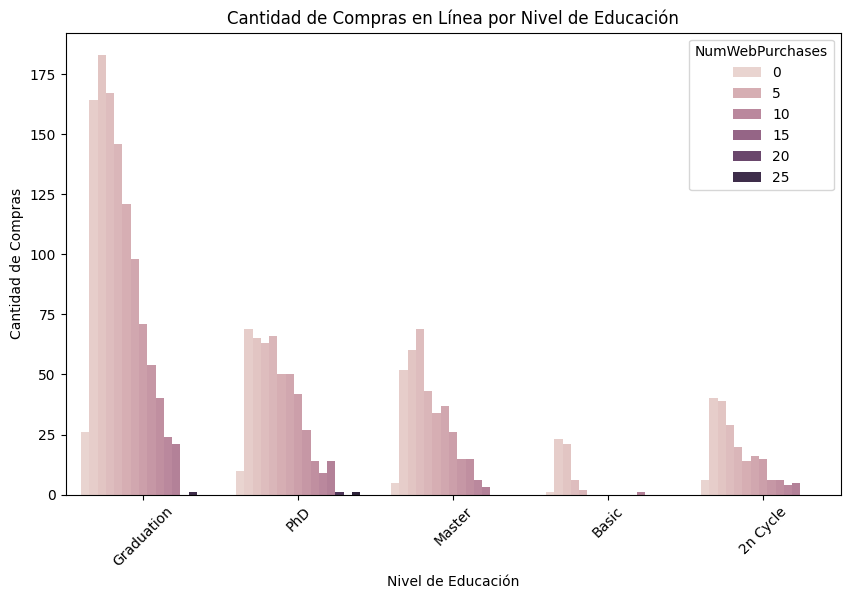

In [80]:

plt.figure(figsize=(10, 6))
sns.countplot(x='Education', data=datos_sin_na, hue='NumWebPurchases')
plt.title('Cantidad de Compras en Línea por Nivel de Educación')
plt.xlabel('Nivel de Educación')
plt.ylabel('Cantidad de Compras')
plt.xticks(rotation=45)
plt.show()


En esta gráfica de barras se puede ver que aquellos con educación básica son los que menos compran en el sitio web, mientras aquellos graduados son los que más compran

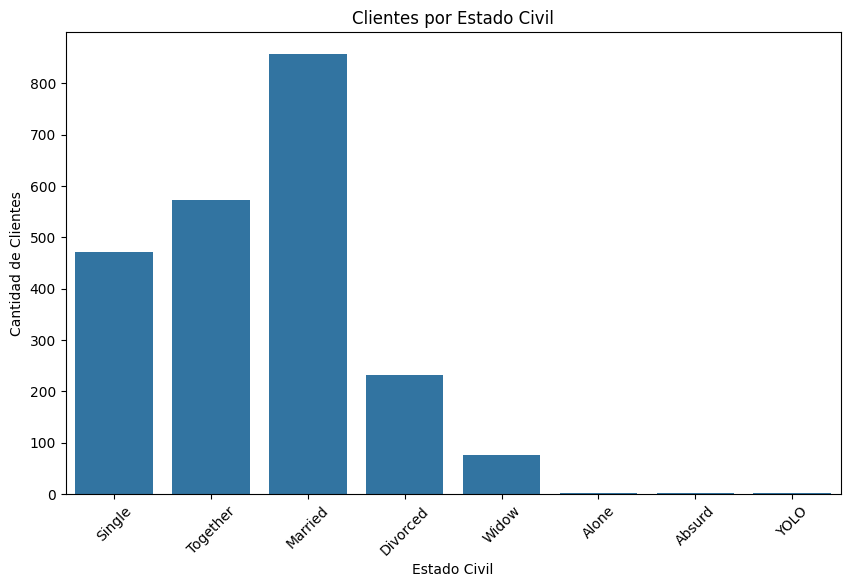

In [31]:

plt.figure(figsize=(10, 6))
sns.countplot(x='Marital_Status', data=datos_sin_na)
plt.title('Clientes por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)
plt.show()


En esta gráfica se muestra que la mayor cantidad de clientes están casados, seguidos por aquellos en una relación formal que aún no se han casado. La menor cantidad de clientes están solos, piensan que es absurdo o creen que solo se vive una vez

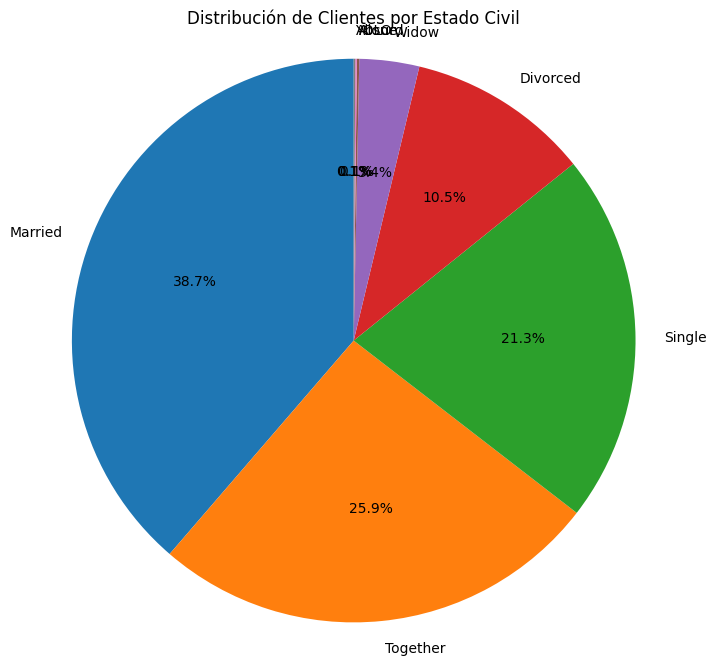

In [33]:
marital_status_counts = datos_sin_na['Marital_Status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(marital_status_counts, labels=marital_status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Clientes por Estado Civil')
plt.axis('equal')
plt.show()


Esta gráfica muestra de forma diferente lo que la gráfica anterior mostraba, utilizando porcentajes para mostrar el peso que tiene cada respuesta

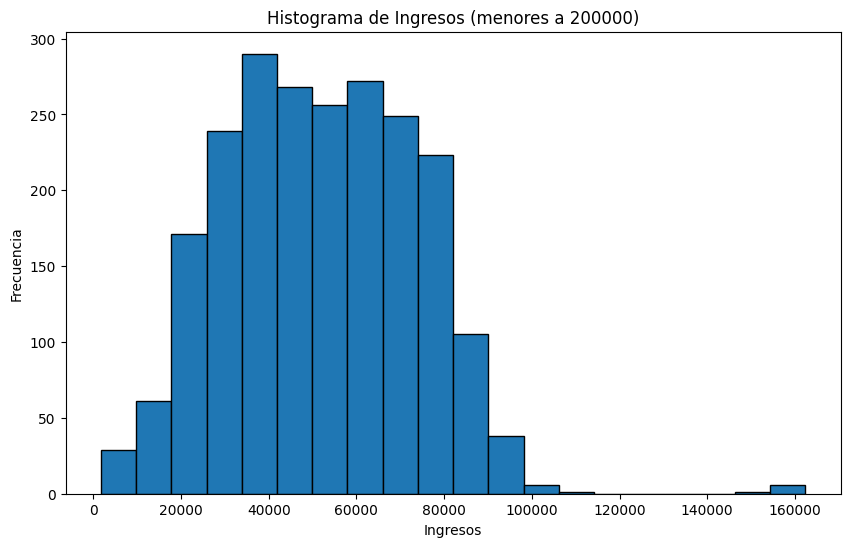

In [34]:

ingresos_menores_200000 = datos_sin_na[datos_sin_na['Income'] < 200000]

plt.figure(figsize=(10, 6))
plt.hist(ingresos_menores_200000['Income'], bins=20, edgecolor='black')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Ingresos (menores a 200000)')
plt.show()


El histograma muestra que la mayoría de clientes tienen ingresos inferiores a los 80000, habiendo una cantidad mínima cuyo ingreso supera los 140000

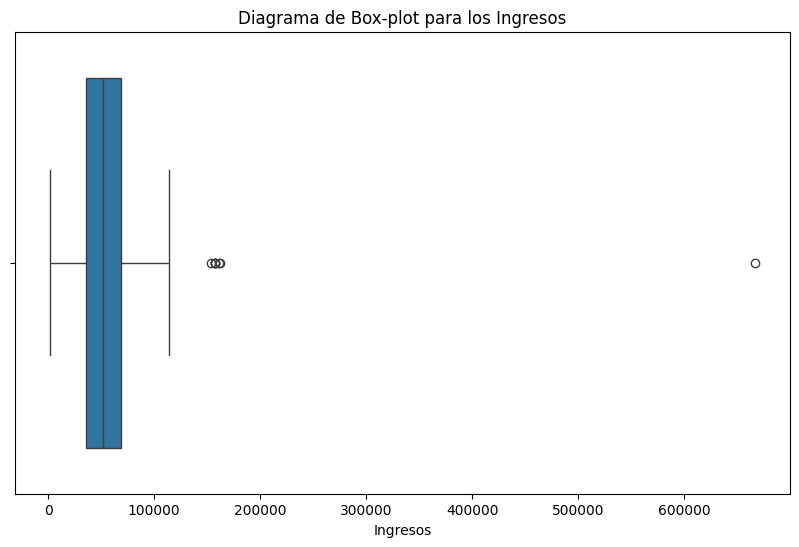

In [35]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=datos_sin_na['Income'])
plt.xlabel('Ingresos')
plt.title('Diagrama de Box-plot para los Ingresos')
plt.show()


Este gráfico muestra que la tendencia de ingresos de los clientes se encuentran alrededor de los 100000 o inferior, con algunos casos especiales cuyos ingresos superan esta cifra

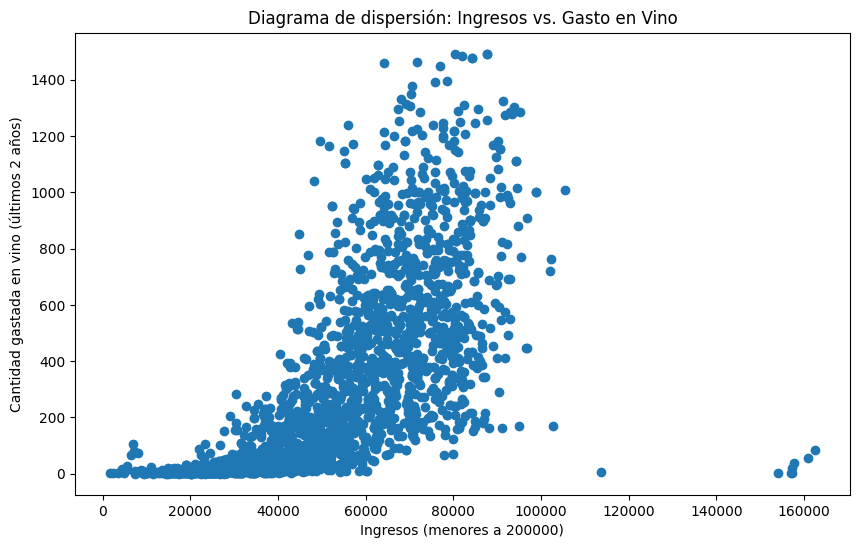

In [36]:

plt.figure(figsize=(10, 6))
plt.scatter(ingresos_menores_200000['Income'], ingresos_menores_200000['MntWines'])
plt.xlabel('Ingresos (menores a 200000)')
plt.ylabel('Cantidad gastada en vino (últimos 2 años)')
plt.title('Diagrama de dispersión: Ingresos vs. Gasto en Vino')
plt.show()


Esta gráfica toma la forma de una campana, mostrando que los que gastan más dinero en vino son aquellos que tienen ingresos medios, teniendo en cuenta que se están analizando los ingresos inferiores a 200000.